In [1]:
%matplotlib inline
import logging

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import yappi
import pandas as pd

import scopesim as sim
import scopesim_templates as sim_tp
from scopesim.utils import from_currsys

from zs_scopesim_tools.helpers import (
    configure_path_and_logging,
    disable_scopesim_top_level_catch,
    ignore_warnings,
    print_yappi_stats as print_prof,
    warning_prevent_sync_alt_ra_dec,
)
from zs_scopesim_tools.sources import (
    ab_magnitude_flat,
    constant_photon_flux_flat,
)
from zs_scopesim_tools.plots import (
    plot_source,
)
from zs_scopesim_tools.validation import (
    fov_image_plane_counts,
    get_effect,
    trace_catalog_table,
)
pd.options.display.max_rows = 999
ignore_warnings()
disable_scopesim_top_level_catch()

## Configure IRDB Path and log level

In [2]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="DEBUG")

## Create the simulator and configure it


In [3]:
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
print(cmd)

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─modes: ['SPEC']
│ ├─pupil_angle: 0
│ ├─object: Test
│ ├─az: 0.0
│ ├─airmass: 1.0
│ ├─seeing: 0.7
│ ├─brightness: dark
│ ├─dit_blue: 300.0
│ ├─ndit_blue: 1
│ ├─dit_green: 300.0
│ ├─ndit_green: 1
│ ├─dit_red: 300.0
│ ├─ndit_red: 1
│ ├─dit_yj: 300.0
│ ├─ndit_yj: 1
│ ├─dit_h: 300.0
│ ├─ndit_h: 1
│ ├─dit_k: 300.0
│ └─ndit_k: 1
├─ATMO:
│ ├─background:
│ │ ├─filter_name: R
│ │ ├─value: 22.0
│ │ └─unit: mag
│ ├─location: MaunaKea
│ ├─altitude: 4123
│ ├─longitude: -155.4744
│ ├─latitude: 19.8263
│ ├─temperature: 2.5
│ ├─humidity: 0.1
│ ├─pressure: 0.62
│ ├─pwv: 2.5
│ ├─x_co2: 450
│ ├─airmass: !OBS.airmass
│ ├─pupil_angle: !OBS.pupil_angle
│ ├─pixel_scale: !INST.pixel_scale
│ └─seeing: !OBS.seeing
├─TEL:
│ ├─telescope: keck
│ └─temperature: !ATMO.temperature
├─INST:
│ ├─temperature: -80
│ ├─pixel_scale: 0.159574468085
│ ├─plate_scale: 10.638297872333334
│ ├─decouple_detector_from_sky_headers: True
│ ├─include_diffuse_emmisivity: True
│ ├─v

## Build the opical train

In [4]:
warning_prevent_sync_alt_ra_dec(cmd)

astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - WARNING: Target coord !OBS.alt not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.ra not set in !OBS config.
astar.scopesim.utils - WARNING: Target coord !OBS.dec not set in !OBS config.
astar.scopesim.utils - Setting coordinates from alt/airmass, location and obstime input.


In [5]:
# %%prun -l 20 -s cumulative # doesn't seem to generate any output (and might not use yappi)
# zs = sim.OpticalTrain(cmd)

yappi.clear_stats()
yappi.set_clock_type("wall")  # or "cpu"

yappi.start()
zs = sim.OpticalTrain(cmd)
yappi.stop()

astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - Using !OBS.brightness dark for observation time
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-06-15T10:21:53.856.
astar.scopesim.utils - Setting coordinates from ra/dec input.
astar.scopesim.utils - ra/dec in str, assuming hourangle/degree units.
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE mo

In [6]:
print_prof()


Clock type: WALL
Ordered by: tsub, desc

name                                                                              ncall       tsub        ttot        tavg        
/Users/jibailey/miniforge3/envs/zssim/lib/python3.14/asyncio/tasks.py:687 sleep   3           20.029454   20.029529   6.676510  
../envs/zssim/lib/python3.14/site-packages/astropy/table/column.py:222 <genexpr>  22001163    5.873374    8.003502    0.000000  
..3.14/site-packages/astropy/table/column.py:164 _convert_sequence_data_to_array  79          2.502448    10.591180   0.134066  
..opeSim/scopesim/effects/sky_ter_curves.py:178 PalaceAirglowEmission.run_palace  1           1.835634    10.844409   10.844409 
..m/lib/python3.14/site-packages/astropy/io/ascii/fastbasic.py:68 FastBasic.read  4987        1.533780    1.703436    0.000342  
..b/python3.14/site-packages/astropy/io/ascii/core.py:809 EcsvData.process_lines  6711        1.127517    3.296268    0.000491  
..envs/zssim/lib/python3.14/site-packages/astropy/io/

Check that FoV's are defined as expected. The trace catalog is taken from the in-memory `trace_list_analytical` effect loaded into this `OpticalTrain`, then compared to the FoV image-plane split.

In [7]:
trace_list = get_effect(zs, "trace_list_analytical")
ecat = trace_catalog_table(trace_list)
display(ecat.show_in_notebook(display_length=-1))
print(f"Trace list contains {len(ecat)} traces.")
print(f"Number of traces per image plane: {np.unique(list(ecat['image_plane_id']), return_counts=True)}")

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

Trace list contains 120 traces.
Number of traces per image plane: (array([0, 1, 2, 3, 4, 5]), array([26, 26, 22, 25, 12,  9]))


In [8]:
display(fov_image_plane_counts(zs))
# It is ok if some are off by one, those are traces at the edgees that get cutoff by the dichroic settings.

astar.scopesim.optics.fov_manager - Returning existing fovs_list.


image_plane_id,n_fovs
int64,int64
0,26
1,26
2,22
3,25
4,12
5,9


## Tweak what effects are included if desired

In [9]:
# for effect in ['maunakea_atmospheric_transmission','seeing_psf','telescope_reflection','Selector','trace_eff','detector_qe']:
#     zs[effect].include = False
zs.effects.show_in_notebook(display_length=-1)

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

## Sky background sanity check

In [10]:
# Load the effect instances for the different sky background components
sky_tx_therm = [eff for eff in zs.optics_manager.all_effects if eff.display_name=="atmo_transmission"][0]
sky_tx0_cont = [eff for eff in zs.optics_manager.all_effects if eff.display_name=="continuum_emission"][0]
sky_tx0_palace = [eff for eff in zs.optics_manager.all_effects if eff.display_name=="airglow_and_interline_continuum"][0]

# Get emission arrays for each component
wave_th, flux_th = sky_tx_therm.emission._get_arrays(wavelengths=None)
wave_th = wave_th.to(u.um)

wave_cont, flux_cont = sky_tx0_cont.emission._get_arrays(wavelengths=None)
wave_cont = wave_cont.to(u.um)

wave_line, flux_line = sky_tx0_palace.line_TER.emission._get_arrays(wavelengths=None)
wave_line = wave_line.to(u.um)

wave_res, flux_res = sky_tx0_palace.continuum_TER.emission._get_arrays(wavelengths=None)
wave_res = wave_res.to(u.um)

# simple resample all to a common wavelength grid for plotting
common_wave = np.linspace(0.3, 2.5, 10001) * u.um
from scipy.interpolate import CubicSpline
from synphot.units import convert_flux
flux_th_interp = CubicSpline(wave_th, flux_th)(common_wave)
flux_cont_interp = CubicSpline(wave_cont, flux_cont)(common_wave)
flux_line_interp = CubicSpline(wave_line, flux_line)(common_wave)
flux_res_interp = CubicSpline(wave_res, flux_res)(common_wave)
# convert to AB mag for plotting
flux_th_erg = convert_flux(wavelengths=common_wave, fluxes=flux_th_interp, out_flux_unit='abmag')
flux_cont_erg = convert_flux(wavelengths=common_wave, fluxes=flux_cont_interp, out_flux_unit='abmag')
flux_line_erg = convert_flux(wavelengths=common_wave, fluxes=flux_line_interp, out_flux_unit='abmag')
flux_res_erg = convert_flux(wavelengths=common_wave, fluxes=flux_res_interp, out_flux_unit='abmag')

#### Plot it

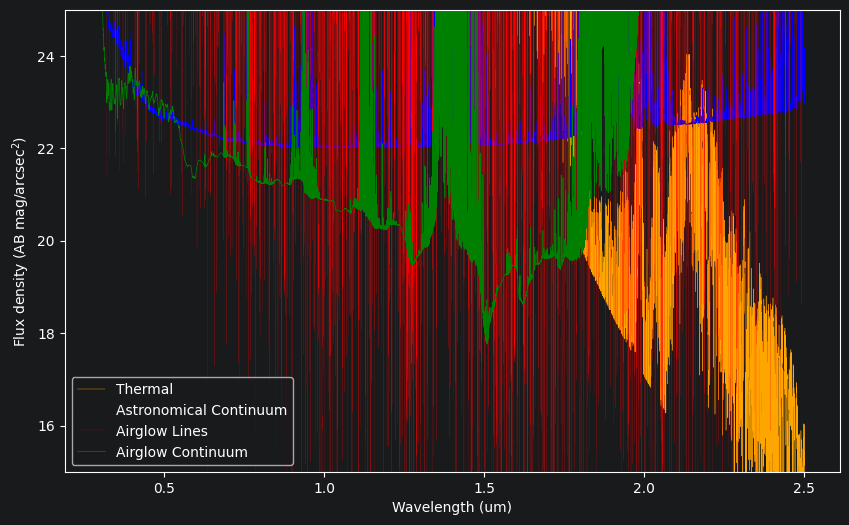

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(common_wave, flux_th_erg, label='Thermal', color='orange', lw=0.3)
plt.plot(common_wave, flux_cont_erg, label='Astronomical Continuum', color='blue', lw=0.5)
plt.plot(common_wave, flux_line_erg, label='Airglow Lines', color='red', lw=0.1)
plt.plot(common_wave, flux_res_erg, label='Airglow Continuum', color='green', lw=0.5)
plt.xlabel("Wavelength (um)")
plt.ylabel(r"Flux density (AB mag/arcsec$^2$)")
plt.legend()
plt.ylim(15,25)
# plt.xlim(0.3, 1.0)
plt.show()

# Make and plot sources

(<Figure size 600x200 with 2 Axes>,
 array([[<Axes: title={'center': 'Spatial Profile'}>,
         <Axes: title={'center': 'Spectrum'}>]], dtype=object))

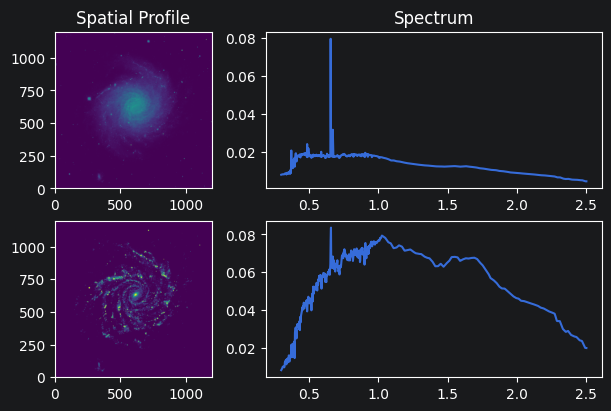

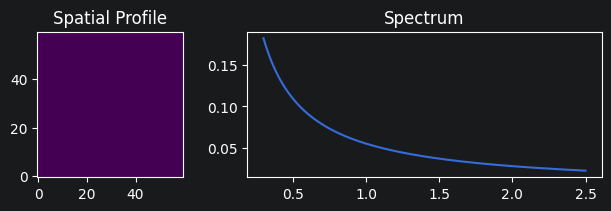

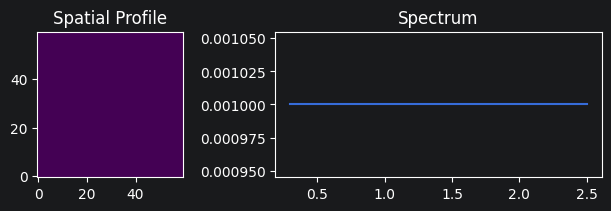

In [12]:
# Galaxy
gal = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(15, 15)*u.mag)
gal.shift(dy=-30*0.004)
plot_source(gal)

# Uniformly source with const AB mag
flat1 = ab_magnitude_flat(mag=10, extent=60)
plot_source(flat1)

# Uniformly illuminated source with a const photon flux density of 1 photon/s/cm^2/Angstrom
flat2 = constant_photon_flux_flat(amplitude=0.001, extent=60)
plot_source(flat2)


## Simulate it!

In [13]:
logging.getLogger('astar.scopesim').setLevel(logging.WARNING)
yappi.clear_stats()
yappi.set_clock_type("wall")  # or "cpu"

yappi.start()
zs.observe(flat2) ## observes empty sky if no source is given
yappi.stop()
logging.getLogger('astar.scopesim').setLevel(logging.DEBUG)

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOVs:   0%|          | 0/120 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

astar.scopesim.utils - WARNING: Obstime is not after sunset!


 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

...

 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

 FOV effects:   0%|          | 0/9 [00:00<?, ?it/s]

In [14]:
print_prof('ttot')


Clock type: WALL
Ordered by: ttot, desc

name                                                                              ncall       tsub        ttot        tavg        
..te-packages/IPython/core/interactiveshell.py:3712 ZMQInteractiveShell.run_code  1           0.000005    117.437921  117.437921
..s/gn/nqgb0s9n3pj4lxzk_lbbc_1c0000gp/T/ipykernel_95063/3878550426.py:1 <module>  2/1         0.000007    117.437914  58.718957 
..ibailey/src/ScopeSim/scopesim/optics/optical_train.py:199 OpticalTrain.observe  1           0.325002    117.437907  117.437907
..im/lib/python3.14/asyncio/base_events.py:1977 _UnixSelectorEventLoop._run_once  3646        0.021344    110.472121  0.030300  
..ey/miniforge3/envs/zssim/lib/python3.14/selectors.py:540 KqueueSelector.select  3646        0.010390    108.433234  0.029740  
/Users/jibailey/miniforge3/envs/zssim/lib/python3.14/asyncio/tasks.py:687 sleep   11          100.054114  100.054374  9.095852  
/Users/jibailey/miniforge3/envs/zssim/lib/python3.14/

#### Read it out

In [15]:
hdul = zs.readout()
hdul

astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: None given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 300.0 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, s

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x129659310>, <astropy.io.fits.hdu.image.ImageHDU object at 0x128f39f90>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x128f38050>, <astropy.io.fits.hdu.image.ImageHDU object at 0x128f3b610>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x128f3bed0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x128dc5590>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x128b4b250>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1290a8050>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1290a8410>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1290a8550>],
 [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1290a8690>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1290a87d0>]]

## Show it

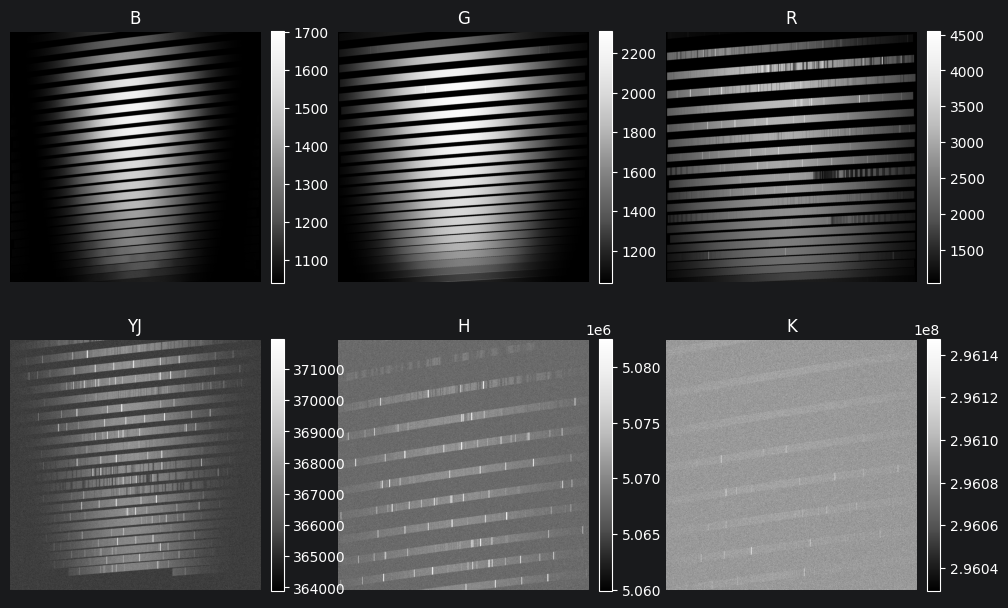

In [16]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
i = 0
for ax, imhdu in zip(axes.flat, hdul):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    imhdu.writeto(f"zspec_{titles[i]}.fits", overwrite=True)
    i += 1

plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.savefig(f"spec_echellogram.png", dpi=300)
